
# Edge AI Assignment: Neural Network from Scratch (Checkerboard Classification)

## Objective
Build a simple neural network **from scratch (no ML libraries)** to classify a 2D checkerboard pattern.

You will:
- Implement forward propagation
- Implement backpropagation
- Train a small neural network
- Visualize the decision boundary

---

## Dataset Concept
We generate (x, y) points and assign labels based on a checkerboard pattern.

This is a **non-linear classification problem** (like XOR, but extended to 2D).


In [ ]:

import numpy as np
import matplotlib.pyplot as plt


## Step 1: Generate Checkerboard Data

In [ ]:

def generate_data(n_samples=500, k=4):
    X = np.random.uniform(-1, 1, (n_samples, 2))

    # Checkerboard labels
    y = ((np.floor((X[:,0]+1)*k) + np.floor((X[:,1]+1)*k)) % 2)

    return X, y.reshape(-1, 1)

X, y = generate_data()


## Visualize Dataset

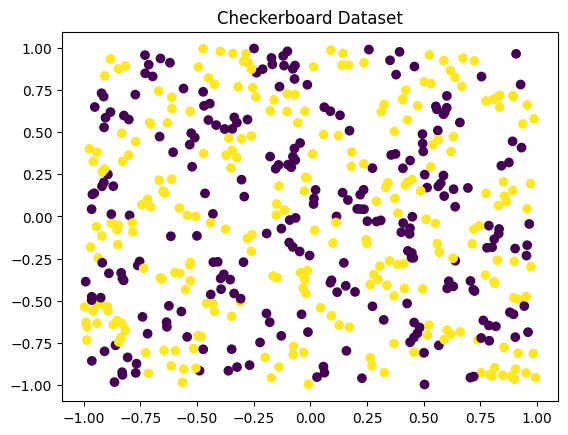

In [ ]:

plt.scatter(X[:,0], X[:,1], c=y.flatten())
plt.title("Checkerboard Dataset")
plt.show()



## Step 2: Build Neural Network

Architecture:
- Input: 2 neurons (x, y)
- Hidden: YOU DECIDE
- Output: 1 neuron (sigmoid)

Fill in missing parts.


In [ ]:

# Initialize weights
def init_params(input_size, hidden_size, output_size):
    W1 = np.random.randn(input_size, hidden_size)
    b1 = np.zeros((1, hidden_size))

    W2 = np.random.randn(hidden_size, output_size)
    b2 = np.zeros((1, output_size))

    return W1, b1, W2, b2


## Activation Functions

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

## Forward Pass

In [ ]:

def forward(X, W1, b1, W2, b2):
    # 1. Hidden layer linear combination
    Z1 = np.dot(X, W1) + b1
    # 2. Activation
    A1 = sigmoid(Z1)
    # 3. Output layer
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    # 4. Return output + intermediates
    return A2, Z1, A1, Z2


## Loss Function

In [ ]:

def compute_loss(y_true, y_pred):
    # Binary cross-entropy
    # Ensure numerical stability by clipping predictions
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss


## Backpropagation

In [ ]:

def backward(X, y, W1, b1, W2, b2, cache):
    A2, Z1, A1, Z2 = cache
    m = y.shape[0]

    # Gradients for output layer
    dZ2 = A2 - y # Derivative of BCE loss with sigmoid output w.r.t Z2
    dW2 = (1 / m) * np.dot(A1.T, dZ2)
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

    # Gradients for hidden layer
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1) # Element-wise multiplication for sigmoid derivative
    dW1 = (1 / m) * np.dot(X.T, dZ1)
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


## Training Loop

In [ ]:

def train(X, y, hidden_size=8, lr=0.1, epochs=1000):
    W1, b1, W2, b2 = init_params(2, hidden_size, 1)

    for epoch in range(epochs):
        # Forward
        A2, Z1, A1, Z2 = forward(X, W1, b1, W2, b2)

        # Loss
        loss = compute_loss(y, A2)

        # Backward
        dW1, db1, dW2, db2 = backward(X, y, W1, b1, W2, b2, (A2, Z1, A1, Z2))

        # Update weights
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return W1, b1, W2, b2


## Visualize Decision Boundary

In [ ]:
def plot_decision_boundary(X, y, model):
    xx, yy = np.meshgrid(np.linspace(-1,1,100), np.linspace(-1,1,100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Unpack the model parameters (W1, b1, W2, b2) from the 'model' tuple
    W1, b1, W2, b2 = model

    # Run the forward pass on the grid using the helper function
    A2_grid, _, _, _ = forward(grid, W1, b1, W2, b2)

    Z = A2_grid.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=y.flatten())
    plt.title("Decision Boundary")
    plt.show()

## Run Training

Epoch 0, Loss: 1.1583
Epoch 100, Loss: 0.6985
Epoch 200, Loss: 0.6954
Epoch 300, Loss: 0.6939
Epoch 400, Loss: 0.6931
Epoch 500, Loss: 0.6927
Epoch 600, Loss: 0.6924
Epoch 700, Loss: 0.6923
Epoch 800, Loss: 0.6922
Epoch 900, Loss: 0.6922


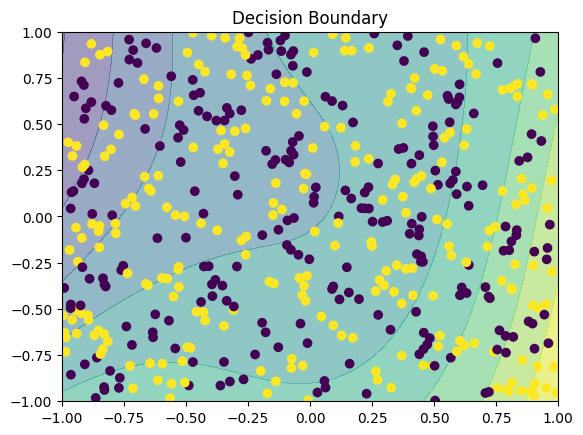

In [ ]:

# Train your model. The train function returns W1, b1, W2, b2 as a tuple.
model = train(X, y)

# Plot the decision boundary using the trained model
plot_decision_boundary(X, y, model)


---

## ⭐ Extra Credit ( For Concept And Code, 20% add on )

### Circle Classification Problem

Instead of a checkerboard, classify points based on whether they lie inside a circle:

- Input: (x, y)
- Output: 1 if inside circle, else 0

Decision boundary:
x² + y² < r²

### Questions:
1. Why is this non-linear?
2. Would a single-layer perceptron work?
3. How would the decision boundary differ from the checkerboard?

---



## Generate Circular Dataset (New Function)

In [ ]:
def generate_circular_data(n_samples=500, radius=0.5):
    X_new = np.random.uniform(-1, 1, (n_samples, 2))

    # Circular labels: 1 if inside circle, 0 if outside
    y_new = (np.sum(X_new**2, axis=1) < radius**2).astype(int)

    return X_new, y_new.reshape(-1, 1)

X_circle, y_circle = generate_circular_data()

## Visualize Circular Dataset

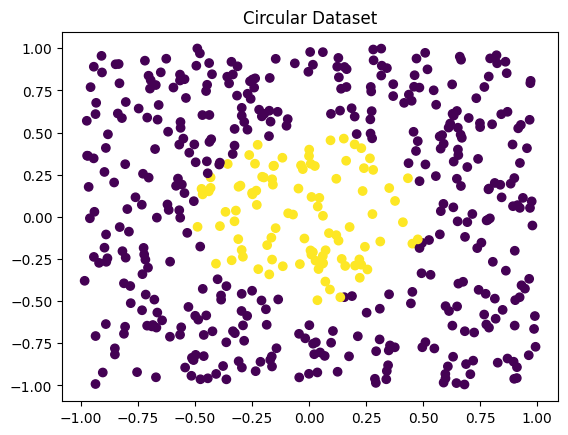

In [ ]:
plt.scatter(X_circle[:,0], X_circle[:,1], c=y_circle.flatten())
plt.title("Circular Dataset")
plt.show()

## Train Model on Circular Dataset

Epoch 0, Loss: 0.5567
Epoch 100, Loss: 0.4927
Epoch 200, Loss: 0.4855
Epoch 300, Loss: 0.4810
Epoch 400, Loss: 0.4771
Epoch 500, Loss: 0.4731
Epoch 600, Loss: 0.4687
Epoch 700, Loss: 0.4638
Epoch 800, Loss: 0.4584
Epoch 900, Loss: 0.4525
Epoch 1000, Loss: 0.4462
Epoch 1100, Loss: 0.4393
Epoch 1200, Loss: 0.4320
Epoch 1300, Loss: 0.4244
Epoch 1400, Loss: 0.4164
Epoch 1500, Loss: 0.4081
Epoch 1600, Loss: 0.3995
Epoch 1700, Loss: 0.3908
Epoch 1800, Loss: 0.3819
Epoch 1900, Loss: 0.3729


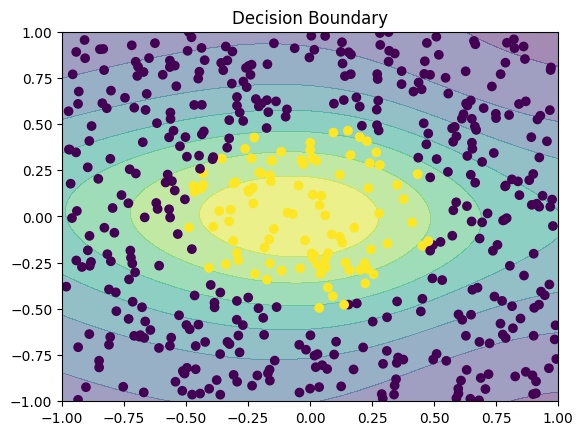

In [ ]:
# Train your model on the new circular data
model_circle = train(X_circle, y_circle, hidden_size=8, lr=0.1, epochs=2000)

# Plot the decision boundary using the trained model
plot_decision_boundary(X_circle, y_circle, model_circle)

## Improving the Model: Activation Functions

Activation functions introduce non-linearity into the network, allowing it to learn complex patterns. While sigmoid is used in the output layer for binary classification, other functions like ReLU are often preferred for hidden layers due to their computational efficiency and ability to mitigate the vanishing gradient problem.

### Rectified Linear Unit (ReLU)

*   **Function**: `f(x) = max(0, x)`
*   **Derivative**: `f'(x) = 1` if `x > 0`, and `0` otherwise.

Let's define ReLU and its derivative.

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

Now, let's update our `forward`, `backward`, and `train` functions to allow us to specify the hidden layer's activation function.

In [ ]:
# Update forward pass to accept a hidden activation function
def forward(X, W1, b1, W2, b2, hidden_activation_fn=sigmoid):
    # 1. Hidden layer linear combination
    Z1 = np.dot(X, W1) + b1
    # 2. Activation for hidden layer
    A1 = hidden_activation_fn(Z1)
    # 3. Output layer linear combination
    Z2 = np.dot(A1, W2) + b2
    # 4. Output layer activation (always sigmoid for binary classification)
    A2 = sigmoid(Z2)
    # 5. Return output + intermediates
    return A2, Z1, A1, Z2

# Update backward pass to accept a hidden activation derivative
def backward(X, y, W1, b1, W2, b2, cache, hidden_activation_derivative=sigmoid_derivative):
    A2, Z1, A1, Z2 = cache
    m = y.shape[0]

    # Gradients for output layer
    dZ2 = A2 - y # Derivative of BCE loss with sigmoid output w.r.t Z2
    dW2 = (1 / m) * np.dot(A1.T, dZ2)
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

    # Gradients for hidden layer
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * hidden_activation_derivative(A1) # Element-wise multiplication for hidden activation derivative
    dW1 = (1 / m) * np.dot(X.T, dZ1)
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# Update train function to accept hidden activation functions
def train(X, y, hidden_size=8, lr=0.1, epochs=1000, hidden_activation_fn=sigmoid, hidden_activation_derivative=sigmoid_derivative):
    W1, b1, W2, b2 = init_params(2, hidden_size, 1)

    loss_history = []

    for epoch in range(epochs):
        # Forward
        A2, Z1, A1, Z2 = forward(X, W1, b1, W2, b2, hidden_activation_fn=hidden_activation_fn)

        # Loss
        loss = compute_loss(y, A2)
        loss_history.append(loss)

        # Backward
        dW1, db1, dW2, db2 = backward(X, y, W1, b1, W2, b2, (A2, Z1, A1, Z2), hidden_activation_derivative=hidden_activation_derivative)

        # Update weights
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return W1, b1, W2, b2, loss_history

Now let's train a new model for the circular dataset using ReLU as the hidden layer activation function and observe the difference in its performance and decision boundary.

Epoch 0, Loss: 1.7391
Epoch 500, Loss: 0.1237
Epoch 1000, Loss: 0.0876
Epoch 1500, Loss: 0.0739
Epoch 2000, Loss: 0.0658
Epoch 2500, Loss: 0.0599
Epoch 3000, Loss: 0.0556
Epoch 3500, Loss: 0.0518
Epoch 4000, Loss: 0.0488
Epoch 4500, Loss: 0.0463
Epoch 4999, Loss: 0.0441


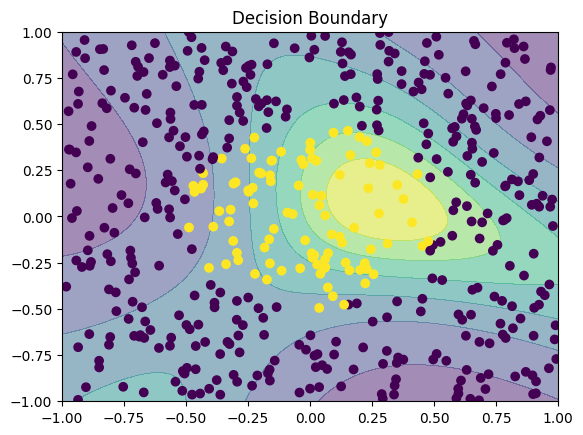

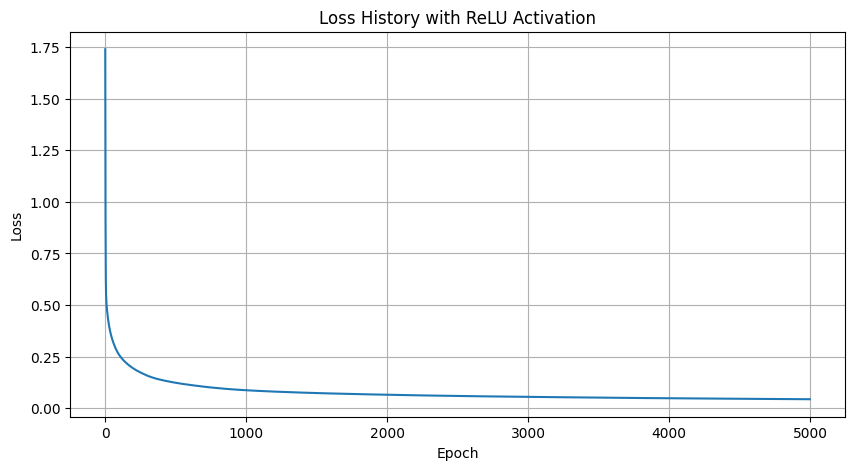

In [ ]:
# Train your model on the new circular data using ReLU as hidden activation
model_relu = train(X_circle, y_circle, hidden_size=32, lr=0.1, epochs=5000, hidden_activation_fn=relu, hidden_activation_derivative=relu_derivative)

# Plot the decision boundary using the trained model with ReLU
# Note: The model tuple now includes loss_history, so we only pass the parameters
plot_decision_boundary(X_circle, y_circle, model_relu[:4])

# Optionally, plot the loss history to see convergence
plt.figure(figsize=(10, 5))
plt.plot(model_relu[4])
plt.title("Loss History with ReLU Activation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Other ways to improve the model include:

*   **Increasing Network Complexity**: Adding more hidden layers or increasing the `hidden_size` (number of neurons in hidden layers) can enable the network to learn more intricate patterns. Be careful not to overfit the data.
*   **Hyperparameter Tuning**: Experimenting with different `learning_rate` values and increasing `epochs` (training iterations) can significantly impact convergence and final accuracy. A learning rate schedule (decreasing learning rate over time) could also be beneficial.
*   **Regularization**: Techniques like L1/L2 regularization or dropout can help prevent overfitting, especially in more complex models.
*   **Batch Processing**: Instead of training on the entire dataset at once (batch gradient descent), using mini-batches can lead to faster and more stable convergence.

## Why is this non-linear?

This is non-linear because the model cannot draw a perfectly straight line through the data points to classify them.  Since the data set is based on a circle, the model needs to used a curve line for decisions.

## Would a single-layer perceptron work?

No - A single-layer perceptron can only learn linearly seperable patterns, which the circular classification model is not.  

## How would the decision boundary differ from the checkerboard?

The decision boundary for the circular classification would fit the model better since there is a defined radius for data points.  The checkerboard is a collection of boundaries made up of vertical and horizontal lines that it has to combine.